Here we will train and optimize Graph Neural Networks (GNN) on the PDBind dataset. We will use data where affinities are evaluated in Kd vallues for couples of molecules and proteins, specifically those of the bigger group of the data set that represent a thousand couples of molecules with hydrolases. In order to have a better distribution of the kd values, we convert them in nM and compute their logarithm value.  

In [1]:
import pandas as pd
from preprocessing import PDBpreprocessing

raw_data = pd.read_csv("LP_PDBBind.csv")

preprocessed_data = PDBpreprocessing(raw_data, category= 'hydrolase', variable='Kd', keep_protein_chain=False, log_transform=True)
print(preprocessed_data.shape)
preprocessed_data.head()

(994, 2)


,smiles,target
0,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619
1,Nc1nc(N2CC[NH+](CCOc3ccc(Br)cc3)CC2)n[nH]1,7.437350
2,NC(=[NH2+])c1ccc(CNC(=O)[C@@H]2CCCN2C(=O)CCC2C...,6.332109
3,CC(=O)N[C@H]1[C@H](O[C@@H]2[C@@H](CO)O[C@@H](O...,9.555728
4,C[C@H]1CCC[C@H](O)CCC/C=C/c2cc(O)cc(O)c2C(=O)O1,6.078825


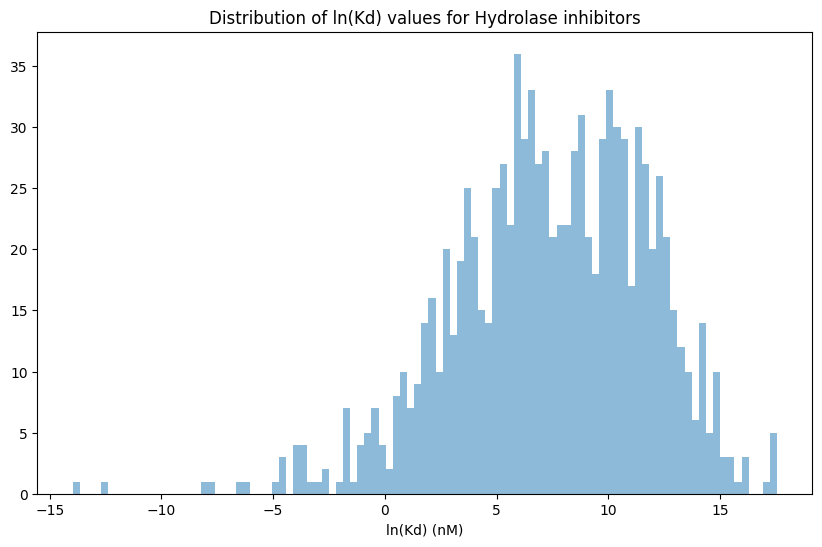

In [2]:
import numpy as np
X_plot = np.linspace(preprocessed_data['target'].min(), preprocessed_data['target'].max(), 100)
Y_plot = np.histogram(preprocessed_data['target'], bins=X_plot)[0]
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(X_plot[:-1], Y_plot, width=np.diff(X_plot), alpha=0.5)
plt.xlabel('ln(Kd) (nM)')
plt.title('Distribution of ln(Kd) values for Hydrolase inhibitors')
plt.show()

In [3]:
pip install 'numpy<2'

Note: you may need to restart the kernel to use updated packages.


Le fichier sp�cifi� est introuvable.


In [4]:
# GNN training + hyperparameter grid (PyG preferred, RDKit-based GNN fallback)
# Hyperparameters to sweep (exactly as requested)
hidden_dims = [32, 64]
lrs = [1e-3]
batch_sizes = [16, 32, 64, 128]
epochs_list = [16, 32, 64, 128]

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Detect availability of PyG (preferred path)
USE_PYG = False
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data, DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool
    from ogb.utils import smiles2graph
    USE_PYG = True
except Exception:
    USE_PYG = False

results = []
best = None
best_mse = float('inf')

if USE_PYG:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def smiles_to_data_pyg(smi, y):
        g = smiles2graph(smi)
        x = torch.tensor(g['node_feat'], dtype=torch.float)
        edge_index = torch.tensor(g['edge_index'], dtype=torch.long)
        if edge_index.dim() == 1:
            edge_index = edge_index.view(2, -1)
        data = Data(x=x, edge_index=edge_index)
        data.y = torch.tensor([y], dtype=torch.float)
        return data

    smiles = preprocessed_data['smiles'].tolist()
    targets = preprocessed_data['target'].astype(float).tolist()
    data_list = []
    for s, t in zip(smiles, targets):
        try:
            data_list.append(smiles_to_data_pyg(s, t))
        except Exception:
            continue
    print(f'Converted {len(data_list)} molecules to PyG graph objects')
    if len(data_list) == 0:
        raise RuntimeError('No molecules converted to graphs (PyG path)')

    train_idx, test_idx = train_test_split(range(len(data_list)), test_size=0.2, random_state=42)
    def make_loader(idxs, batch_size):
        subset = [data_list[i] for i in idxs]
        return DataLoader(subset, batch_size=batch_size, shuffle=True)

    class SimpleGNN(torch.nn.Module):
        def __init__(self, in_channels, hidden_dim, out_dim=1):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.lin = torch.nn.Linear(hidden_dim, out_dim)
        def forward(self, data):
            x, edge_index, batch = data.x, data.edge_index, data.batch
            x = F.relu(self.conv1(x, edge_index))
            x = F.relu(self.conv2(x, edge_index))
            x = global_mean_pool(x, batch)
            return self.lin(x).view(-1)

    in_dim = data_list[0].x.shape[1]

    # grid search over requested hyperparameters
    for hidden in hidden_dims:
        for lr in lrs:
            for batch_size in batch_sizes:
                for epochs in epochs_list:
                    train_loader = make_loader(train_idx, batch_size)
                    test_loader = make_loader(test_idx, batch_size)
                    model = SimpleGNN(in_dim, hidden).to(device)
                    opt = torch.optim.Adam(model.parameters(), lr=lr)
                    loss_fn = torch.nn.MSELoss()

                    # training loop for the chosen number of epochs
                    for ep in range(epochs):
                        model.train()
                        for batch in train_loader:
                            batch = batch.to(device)
                            opt.zero_grad()
                            out = model(batch)
                            loss = loss_fn(out, batch.y.view(-1))
                            loss.backward()
                            opt.step()

                    # evaluation
                    model.eval()
                    ys, ypreds = [], []
                    with torch.no_grad():
                        for batch in test_loader:
                            batch = batch.to(device)
                            out = model(batch)
                            ys.append(batch.y.view(-1).cpu().numpy())
                            ypreds.append(out.cpu().numpy())
                    ys = np.concatenate(ys) if len(ys)>0 else np.array([])
                    ypreds = np.concatenate(ypreds) if len(ypreds)>0 else np.array([])
                    if ys.size == 0:
                        continue
                    mse = mean_squared_error(ys, ypreds)
                    r2 = r2_score(ys, ypreds)
                    results.append({'hidden':hidden, 'lr':lr, 'batch_size':batch_size, 'epochs':epochs, 'mse':mse, 'r2':r2})
                    if mse < best_mse:
                        best_mse = mse
                        best = {'model': model, 'hidden':hidden, 'lr':lr, 'batch_size':batch_size, 'epochs':epochs, 'mse':mse, 'r2':r2, 'test_y': ys, 'test_pred': ypreds}
                    print(f'hidden={hidden} lr={lr} batch={batch_size} epochs={epochs} -> mse={mse:.4f} r2={r2:.4f}')

else:
    # PyG not available: use RDKit-based GNN (must have RDKit + torch)
    try:
        from rdkit import Chem
        import torch
        import torch.nn.functional as F
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        def mol_to_feats_adj(smi):
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                raise ValueError('Invalid SMILES')
            n = mol.GetNumAtoms()
            feats = []
            for atom in mol.GetAtoms():
                feats.append([atom.GetAtomicNum(), atom.GetTotalDegree(), atom.GetFormalCharge(), int(atom.GetIsAromatic())])
            feats = np.array(feats, dtype=float)
            adj = np.zeros((n,n), dtype=float)
            for b in mol.GetBonds():
                i = b.GetBeginAtomIdx(); j = b.GetEndAtomIdx()
                adj[i,j] = 1.0; adj[j,i] = 1.0
            deg = adj.sum(axis=1)
            deg[deg==0]=1.0
            deg_inv = 1.0/deg
            D_inv = np.diag(deg_inv)
            adj_norm = D_inv @ adj
            return feats, adj_norm

        smiles = preprocessed_data['smiles'].tolist()
        targets = preprocessed_data['target'].astype(float).tolist()
        dataset = []
        for s, t in zip(smiles, targets):
            try:
                x, adj = mol_to_feats_adj(s)
                dataset.append({'x': x, 'adj': adj, 'y': float(t)})
            except Exception:
                continue
        print(f'Converted {len(dataset)} molecules (RDKit fallback)')
        if len(dataset) == 0:
            raise RuntimeError('No molecules converted (RDKit fallback)')

        train_idx, test_idx = train_test_split(range(len(dataset)), test_size=0.2, random_state=42)

        class SimpleGNNNoPyG(torch.nn.Module):
            def __init__(self, in_feats, hidden):
                super().__init__()
                self.lin1 = torch.nn.Linear(in_feats, hidden)
                self.lin2 = torch.nn.Linear(hidden, hidden)
                self.out = torch.nn.Linear(hidden, 1)
            def forward(self, x, adj):
                h = F.relu(self.lin1(x))
                m = torch.matmul(adj, h)
                h = F.relu(self.lin2(m))
                g = h.mean(dim=0)
                return self.out(g).view(-1)

        # grid search same as above
        for hidden in hidden_dims:
            for lr in lrs:
                for batch_size in batch_sizes:
                    for epochs in epochs_list:
                        model = SimpleGNNNoPyG(in_feats=4, hidden=hidden).to(device)
                        opt = torch.optim.Adam(model.parameters(), lr=lr)
                        loss_fn = torch.nn.MSELoss()

                        # train for epochs
                        for ep in range(epochs):
                            model.train()
                            for i in train_idx:
                                sample = dataset[i]
                                x = torch.tensor(sample['x'], dtype=torch.float, device=device)
                                adj = torch.tensor(sample['adj'], dtype=torch.float, device=device)
                                y = torch.tensor([sample['y']], dtype=torch.float, device=device)
                                opt.zero_grad()
                                pred = model(x, adj)
                                loss = loss_fn(pred, y)
                                loss.backward()
                                opt.step()

                        # eval
                        model.eval()
                        ys, ypreds = [], []
                        with torch.no_grad():
                            for i in test_idx:
                                sample = dataset[i]
                                x = torch.tensor(sample['x'], dtype=torch.float, device=device)
                                adj = torch.tensor(sample['adj'], dtype=torch.float, device=device)
                                y = float(sample['y'])
                                pred = model(x, adj).cpu().numpy().ravel()[0]
                                ys.append(y)
                                ypreds.append(pred)
                        ys = np.array(ys); ypreds = np.array(ypreds)
                        if ys.size == 0:
                            continue
                        mse = mean_squared_error(ys, ypreds)
                        r2 = r2_score(ys, ypreds)
                        results.append({'hidden':hidden, 'lr':lr, 'batch_size':batch_size, 'epochs':epochs, 'mse':mse, 'r2':r2})
                        if mse < best_mse:
                            best_mse = mse
                            best = {'model': model, 'hidden':hidden, 'lr':lr, 'batch_size':batch_size, 'epochs':epochs, 'mse':mse, 'r2':r2, 'test_y': ys, 'test_pred': ypreds}
                        print(f'hidden={hidden} lr={lr} batch={batch_size} epochs={epochs} -> mse={mse:.4f} r2={r2:.4f}')

    except Exception as e:
        raise RuntimeError('Neither PyG nor RDKit+torch are available; a GNN path requires one of these. Install PyG/OGB or RDKit and torch in your environment.')

# Summarize results and plot heatmaps (batch_size x epochs) for each hidden_dim
try:
    df_res = pd.DataFrame(results)
    if df_res.empty:
        print('No results collected from GNN runs')
    else:
        display(df_res.sort_values('mse').head(10))
        import seaborn as sns
        for hidden in sorted(df_res['hidden'].unique()):
            sub = df_res[df_res['hidden'] == hidden]
            pivot_mse = sub.pivot_table(index='batch_size', columns='epochs', values='mse')
            pivot_r2 = sub.pivot_table(index='batch_size', columns='epochs', values='r2')

            plt.figure(figsize=(8,4))
            plt.suptitle(f'hidden={hidden}')
            plt.subplot(1,2,1)
            sns.heatmap(pivot_mse, annot=True, fmt='.3f', cmap='viridis')
            plt.title('MSE (batch_size x epochs)')

            plt.subplot(1,2,2)
            sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='viridis')
            plt.title('R2 (batch_size x epochs)')
            plt.tight_layout(rect=[0,0,1,0.95])
            plt.show()

        # print best hyperparameters and metrics
        best_idx = df_res['mse'].idxmin()
        best_row = df_res.loc[best_idx]
        print('\nBest hyperparameters (min MSE):')
        print(best_row.to_dict())

        # plot Actual vs Predicted for best
        if best is not None and 'test_y' in best and 'test_pred' in best:
            ys = np.array(best['test_y'])
            ypreds = np.array(best['test_pred'])
            plt.figure(figsize=(6,6))
            plt.scatter(ys, ypreds, alpha=0.6)
            mn = min(ys.min(), ypreds.min())
            mx = max(ys.max(), ypreds.max())
            plt.plot([mn,mx],[mn,mx], color='red', linestyle='--')
            plt.xlabel('Actual target (ln nM)')
            plt.ylabel('Predicted target (ln nM)')
            plt.title('Actual vs Predicted (best model)')
            plt.show()
        else:
            print('Best model/predictions missing; cannot plot Actual vs Predicted')
except Exception as e:
    print('Could not summarize/plot results:', e)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\traitlets\config\application.py", line 1075, in launch

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\traitlets\config\application.py", line 1075, in launch

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\traitlets\config\application.py", line 1075, in launch

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\traitlets\config\application.py", line 1075, in launch

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\33695\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\traitlets\config\application.py", line 1075, in launch

AttributeError: _ARRAY_API not found

RuntimeError: Neither PyG nor RDKit+torch are available; a GNN path requires one of these. Install PyG/OGB or RDKit and torch in your environment.

In [5]:
!pip install ogb

!pip install rdkit-pypi

In [6]:
!pip install --upgrade pip

In [7]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [8]:
# Environment diagnostic + automated safe installs (runs pip using the current Python)
# WARNING: run this in a new/isolated environment (venv or conda) when possible.
import sys, subprocess, json, os
from packaging import version

def run_pip(*args):
    cmd = [sys.executable, '-m', 'pip', 'install', *args]
    print('\n>>', ' '.join(cmd))
    try:
        subprocess.check_call(cmd)
        return True
    except subprocess.CalledProcessError as e:
        print('pip failed:', e)
        return False

print('Python: ', sys.executable)
print('Platform:', sys.platform)

# show key package versions if importable
def safe_version_import(name):
    try:
        m = __import__(name)
        return getattr(m, '__version__', str(m))
    except Exception as e:
        return None

print('numpy:', safe_version_import('numpy'))
print('torch:', safe_version_import('torch'))
print('rdkit:', safe_version_import('rdkit'))
print('ogb:', safe_version_import('ogb'))

# 1) upgrade packaging tools
run_pip('--upgrade', 'pip', 'setuptools', 'wheel')

# 2) If numpy >= 2.0, recommend/downgrade to <2 for compatibility with many binary wheels
import importlib
np_ver = None
try:
    import numpy as _np
    np_ver = version.parse(_np.__version__)
except Exception:
    pass

restart_required = False
if np_ver is not None and np_ver >= version.parse('2.0'):
    print('\nDetected numpy', _np.__version__, '— many binary extension wheels still expect numpy<2.')
    print('Installing numpy<2 to maximize compatibility...')
    ok = run_pip('"numpy<2"')
    if ok:
        restart_required = True
    else:
        print('Failed to change numpy. You can try: python -m pip install "numpy<2"')

# 3) Install CPU-only PyTorch (safe default) — uses PyTorch provided CPU wheels
print('\nInstalling CPU PyTorch (torch, torchvision, torchaudio) — this may take a while')
run_pip('torch', 'torchvision', 'torchaudio', '--index-url', 'https://download.pytorch.org/whl/cpu')

# 4) Install OGB and rdkit-pypi (rdkit-pypi can be fragile on Windows; conda-forge is recommended)
print('\nInstalling ogb and rdkit-pypi (rdkit-pypi may be unreliable on Windows; see notes below)')
run_pip('ogb')
run_pip('rdkit-pypi')

# 5) Try to import torch and determine version for PyG wheels
torch_ok = False
torch_version = None
try:
    import torch
    torch_ok = True
    torch_version = torch.__version__.split('+')[0]  # e.g. '2.2.0'
    print('Imported torch', torch.__version__)
except Exception as e:
    print('Could not import torch after install:', e)

# 6) Attempt PyG wheels installation matched to torch version (CPU)
if torch_ok and torch_version is not None:
    pyg_tag = f'torch-{torch_version}+cpu'
    wheel_index = f'https://data.pyg.org/whl/{pyg_tag}.html'
    print(f'Attempting to install PyG dependencies for torch {torch_version} from {wheel_index}')
    # install the low-level extras then torch-geometric
    for pkg in ['torch-scatter', 'torch-sparse', 'torch-cluster', 'torch-spline-conv']:
        ok = run_pip(pkg, '-f', wheel_index)
        if not ok:
            print(f'Warning: installing {pkg} failed — you may still try conda-forge route.')
    run_pip('torch-geometric')

# Final diagnostics: show versions
print('\nFinal version checks (import attempts)')
print('numpy:', safe_version_import('numpy'))
print('torch:', safe_version_import('torch'))
print('torch_cuda_available (if torch):', end=' ')
try:
    import torch
    print(torch.cuda.is_available())
except Exception:
    print('torch not importable')
print('rdkit:', safe_version_import('rdkit'))
print('ogb:', safe_version_import('ogb'))
print('torch_geometric:', safe_version_import('torch_geometric'))

# Advice / next steps
print('\nNotes and next steps:')
print('- If you installed/changed numpy or torch, you MUST restart the kernel and re-run the notebook cells.')
print("- On Windows, using conda-forge is more reliable for RDKit and some compiled dependencies. Example:")
print('  conda create -n chem python=3.11 -y; conda activate chem')
print('  conda install -c conda-forge rdkit numpy=1.26 pytorch cpuonly -y')
print('  python -m pip install ogb')
print('\nIf the cell above attempted installs and you still see DLL errors (e.g. c10.dll), try:')
print('  - Install Microsoft Visual C++ Redistributable (2015-2022) x64')
print('  - Use conda-forge builds for RDKit and PyTorch')

if restart_required:
    print('\nAutomatic action required: please restart the notebook kernel now and re-run the notebook.')
    try:
        # best-effort kernel restart in Jupyter; may not work in all UIs (VSCode might ignore it)
        from IPython.display import display, Javascript
        display(Javascript('Jupyter.notebook.kernel.restart()'))
    except Exception:
        pass
else:
    print('\nNo forced restart requested by this script; if you installed torch/rdkit just now, consider restarting the kernel.')


Python:  C:\Users\33695\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
Platform: win32
numpy: 2.3.3
torch: None
rdkit: 2022.09.5
torch: None
rdkit: 2022.09.5
ogb: 1.3.6

>> C:\Users\33695\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip setuptools wheel
ogb: 1.3.6

>> C:\Users\33695\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip setuptools wheel

Detected numpy 2.3.3 — many binary extension wheels still expect numpy<2.
Installing numpy<2 to maximize compatibility...

>> C:\Users\33695\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install "numpy<2"

Detected numpy 2.3.3 — many binary extension wheels still expect numpy<2.
Installing numpy<2 to maximize compatibility...

>> C:\Users\33695\AppData\Local\Microsoft\WindowsApps\